# Round 4 — Full Market Analysis

All 12 products across days **1, 2, 3** with bid/ask price movements and counterparty trading behaviour.

## 1 — Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

DATA_DIR = Path("../../historical_data/round_4")

days = [1, 2, 3]
day_colors = {1: "#4C72B0", 2: "#DD8452", 3: "#55A868"}
day_labels  = {1: "Day 1",   2: "Day 2",   3: "Day 3"}

# --- prices ---
price_frames = []
for d in days:
    tmp = pd.read_csv(DATA_DIR / f"prices_round_4_day_{d}.csv", sep=";")
    price_frames.append(tmp)
prices_df = pd.concat(price_frames, ignore_index=True)

# --- trades ---
trade_frames = []
for d in days:
    tmp = pd.read_csv(DATA_DIR / f"trades_round_4_day_{d}.csv", sep=";")
    tmp["day"] = d
    trade_frames.append(tmp)
trades_df = pd.concat(trade_frames, ignore_index=True)

# build global timestamp (day 1 starts at 0)
ticks_per_day = int(prices_df[prices_df["day"] == 1]["timestamp"].max() + 100)
prices_df["global_ts"] = (prices_df["day"] - 1) * ticks_per_day + prices_df["timestamp"]
trades_df["global_ts"] = (trades_df["day"] - 1) * ticks_per_day + trades_df["timestamp"]

PRODUCTS   = sorted(prices_df["product"].unique().tolist())
TRADERS    = sorted(set(trades_df["buyer"].dropna().tolist() + trades_df["seller"].dropna().tolist()))
DELTA1     = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]
VOUCHERS   = [p for p in PRODUCTS if p.startswith("VEV_")]

print(f"Price rows   : {len(prices_df):,}")
print(f"Trade rows   : {len(trades_df):,}")
print(f"ticks_per_day: {ticks_per_day:,}")
print(f"Products ({len(PRODUCTS)}): {PRODUCTS}")
print(f"Traders  ({len(TRADERS)}): {TRADERS}")

Price rows   : 360,000
Trade rows   : 4,281
ticks_per_day: 1,000,000
Products (12): ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
Traders  (7): ['Mark 01', 'Mark 14', 'Mark 22', 'Mark 38', 'Mark 49', 'Mark 55', 'Mark 67']


## 2 — All 12 Products: Bid / Ask Overview Grid

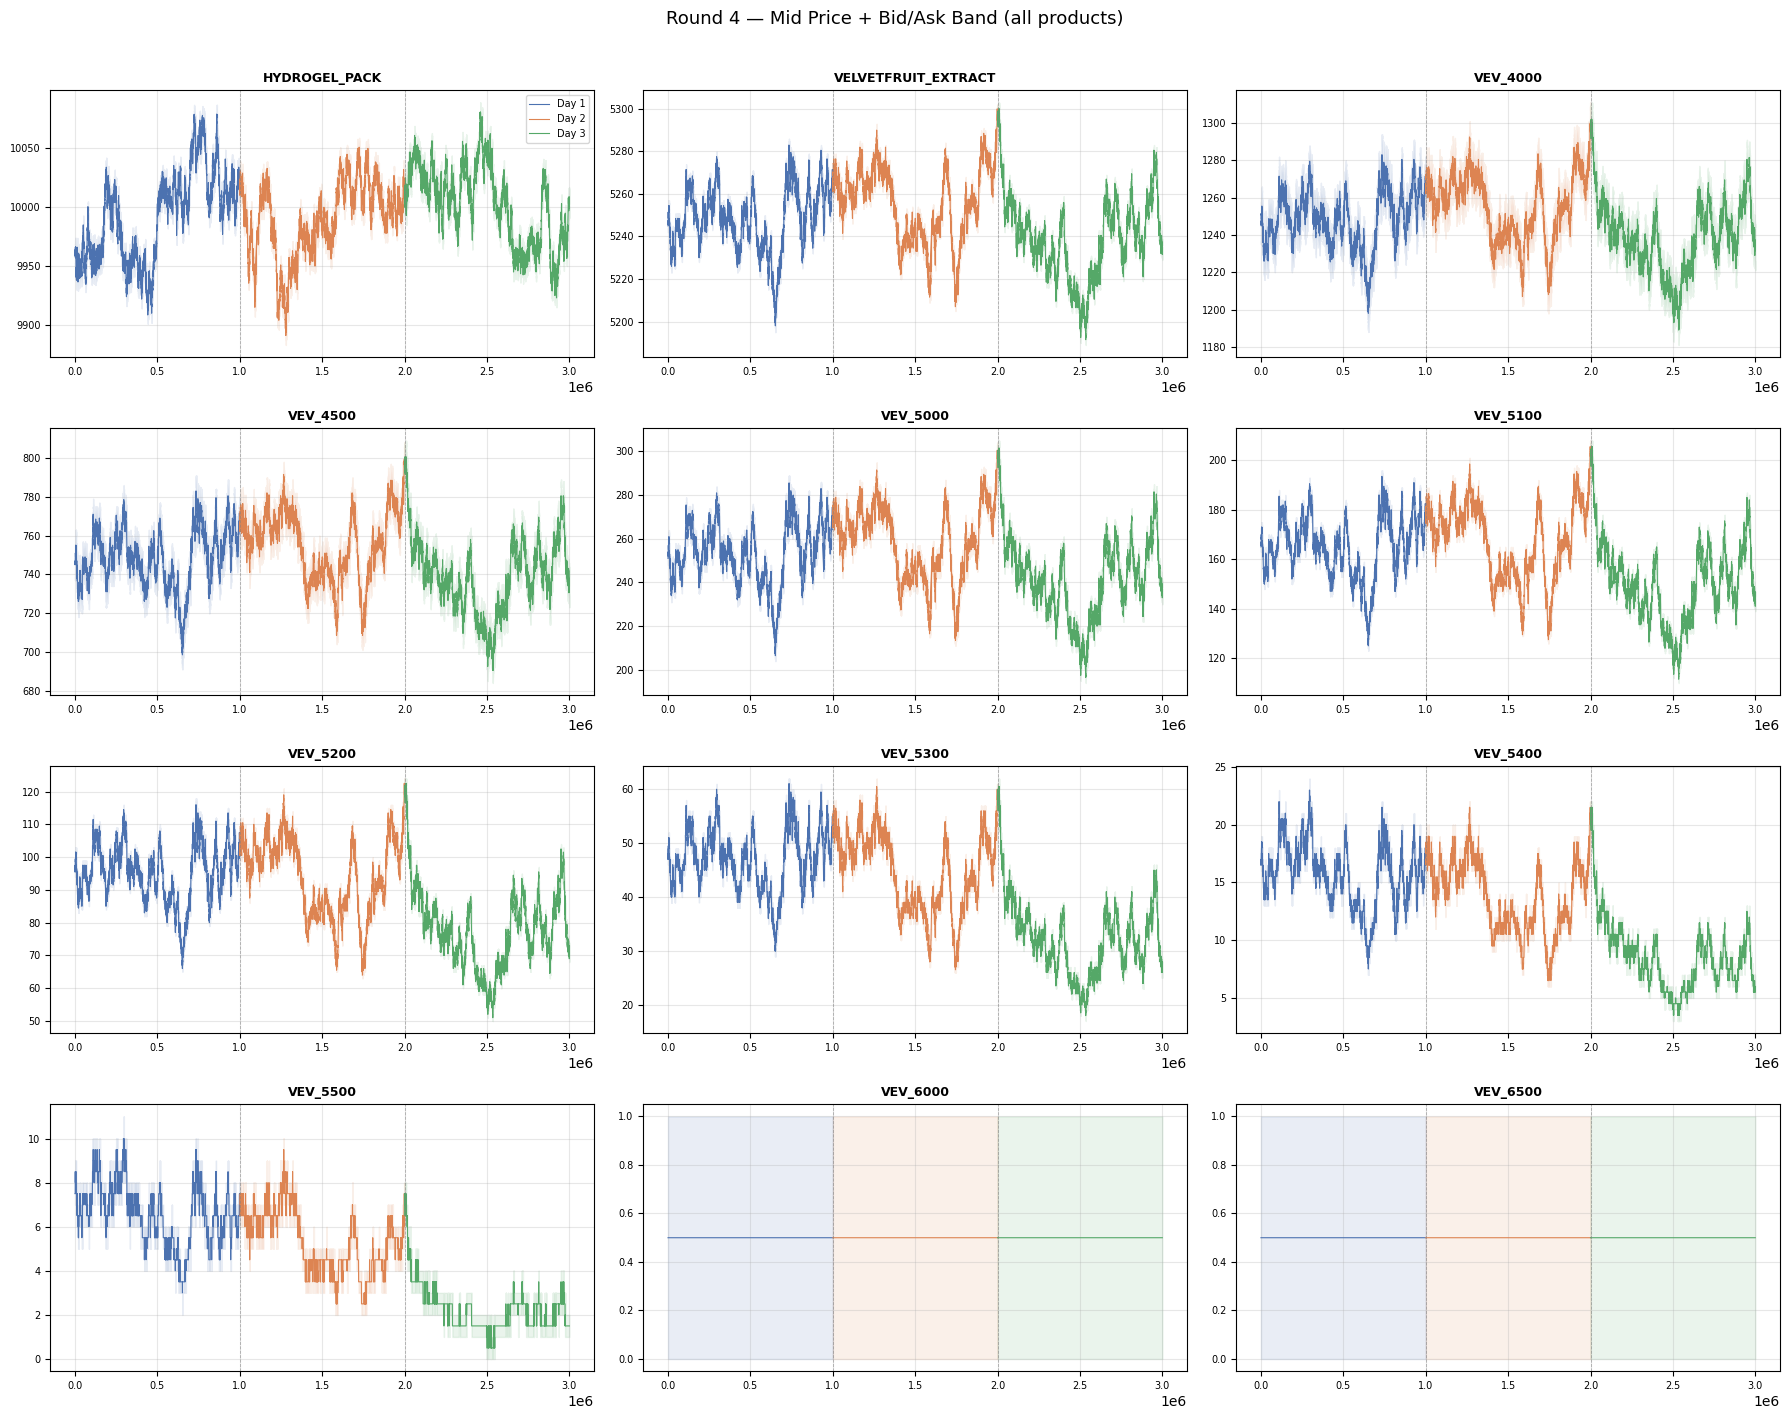

In [2]:
ncols = 3
nrows = int(np.ceil(len(PRODUCTS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for idx, product in enumerate(PRODUCTS):
    ax = axes[idx]
    pdf = prices_df[prices_df["product"] == product].copy()
    for d in days:
        sub = pdf[pdf["day"] == d]
        ax.plot(sub["global_ts"], sub["mid_price"],
                color=day_colors[d], lw=0.8, label=day_labels[d])
        ax.fill_between(sub["global_ts"],
                        sub["bid_price_1"], sub["ask_price_1"],
                        color=day_colors[d], alpha=0.12)
    for i in range(1, len(days)):
        ax.axvline(i * ticks_per_day, color="grey", ls="--", lw=0.6, alpha=0.6)
    ax.set_title(product, fontsize=9, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)
    if idx == 0:
        ax.legend(fontsize=7)

# hide unused axes
for j in range(len(PRODUCTS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Round 4 — Mid Price + Bid/Ask Band (all products)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3 — Delta-1 Products: Detailed Bid / Ask + Spread

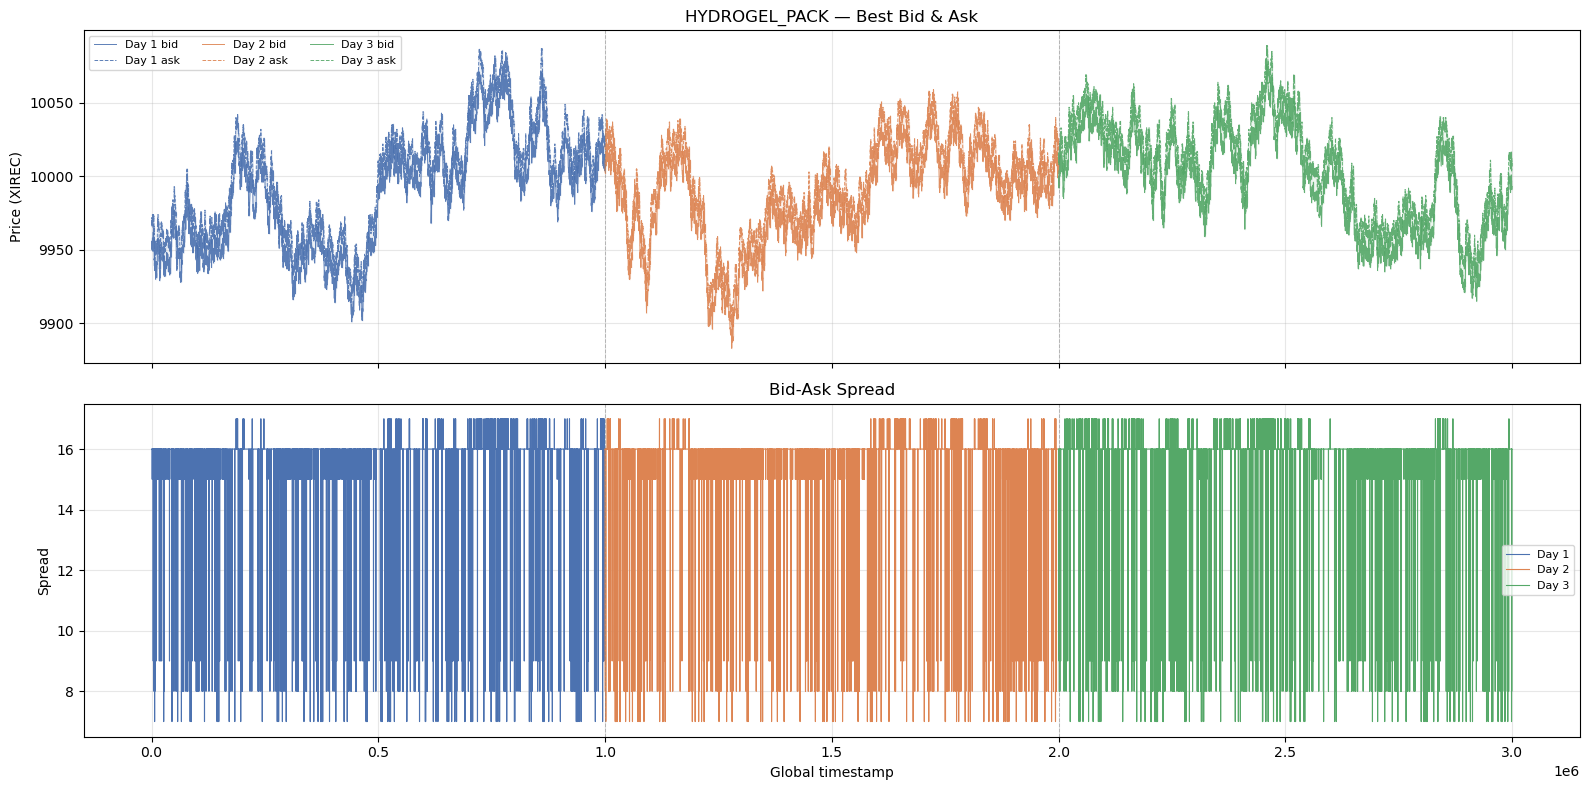

    mid_price                         spread              
         mean    std     min      max   mean   std min max
day                                                       
1     9992.06  37.61  9908.5  10079.0  15.73  1.44   7  17
2     9989.40  31.62  9891.0  10051.0  15.74  1.41   7  17
3    10002.50  32.95  9923.0  10081.0  15.72  1.49   7  17



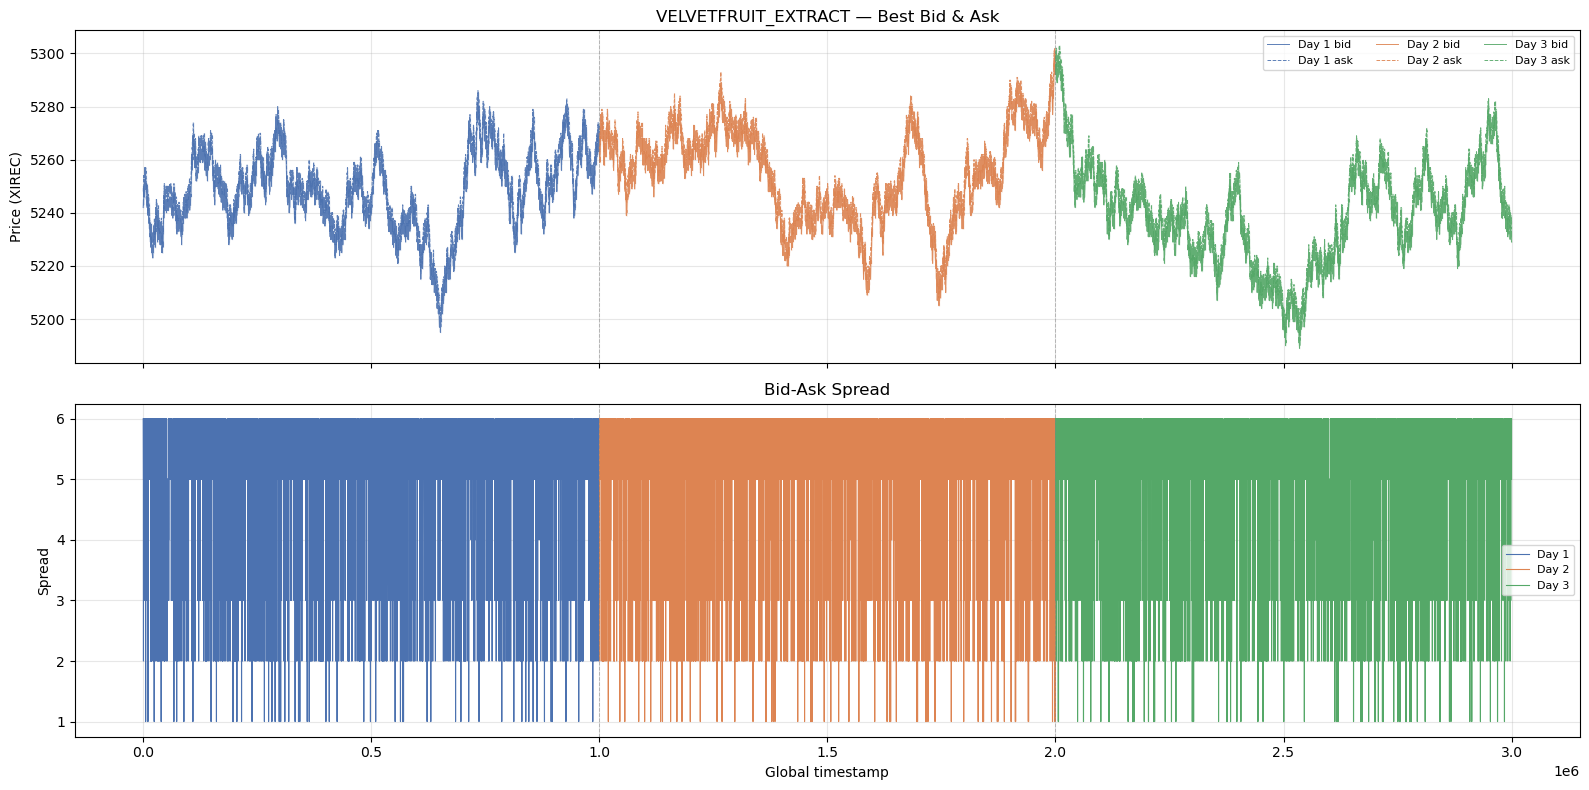

    mid_price                        spread              
         mean    std     min     max   mean   std min max
day                                                      
1     5248.39  14.61  5198.0  5283.0   4.98  0.85   1   6
2     5255.39  16.99  5207.0  5300.0   4.99  0.85   1   6
3     5239.16  18.60  5191.5  5300.0   4.98  0.85   1   6



In [3]:
for product in DELTA1:
    pdf = prices_df[prices_df["product"] == product].copy()
    pdf["spread"] = pdf["ask_price_1"] - pdf["bid_price_1"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

    for d in days:
        sub = pdf[pdf["day"] == d]
        ax1.plot(sub["global_ts"], sub["bid_price_1"],
                 color=day_colors[d], lw=0.7, alpha=0.9, label=f"{day_labels[d]} bid")
        ax1.plot(sub["global_ts"], sub["ask_price_1"],
                 color=day_colors[d], lw=0.7, alpha=0.9, ls="--", label=f"{day_labels[d]} ask")
        ax1.fill_between(sub["global_ts"], sub["bid_price_1"], sub["ask_price_1"],
                         color=day_colors[d], alpha=0.1)
        ax2.plot(sub["global_ts"], sub["spread"],
                 color=day_colors[d], lw=0.8, label=day_labels[d])

    for ax in (ax1, ax2):
        for i in range(1, len(days)):
            ax.axvline(i * ticks_per_day, color="grey", ls="--", lw=0.7, alpha=0.5)
        ax.grid(True, alpha=0.3)

    ax1.set_title(f"{product} — Best Bid & Ask", fontsize=12)
    ax1.set_ylabel("Price (XIREC)")
    ax1.legend(fontsize=8, ncol=3)
    ax2.set_title("Bid-Ask Spread")
    ax2.set_ylabel("Spread")
    ax2.set_xlabel("Global timestamp")
    ax2.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print(pdf.groupby("day")[["mid_price", "spread"]].agg(["mean", "std", "min", "max"]).round(2))
    print()

## 4 — All VEV Vouchers: Strike Price Comparison

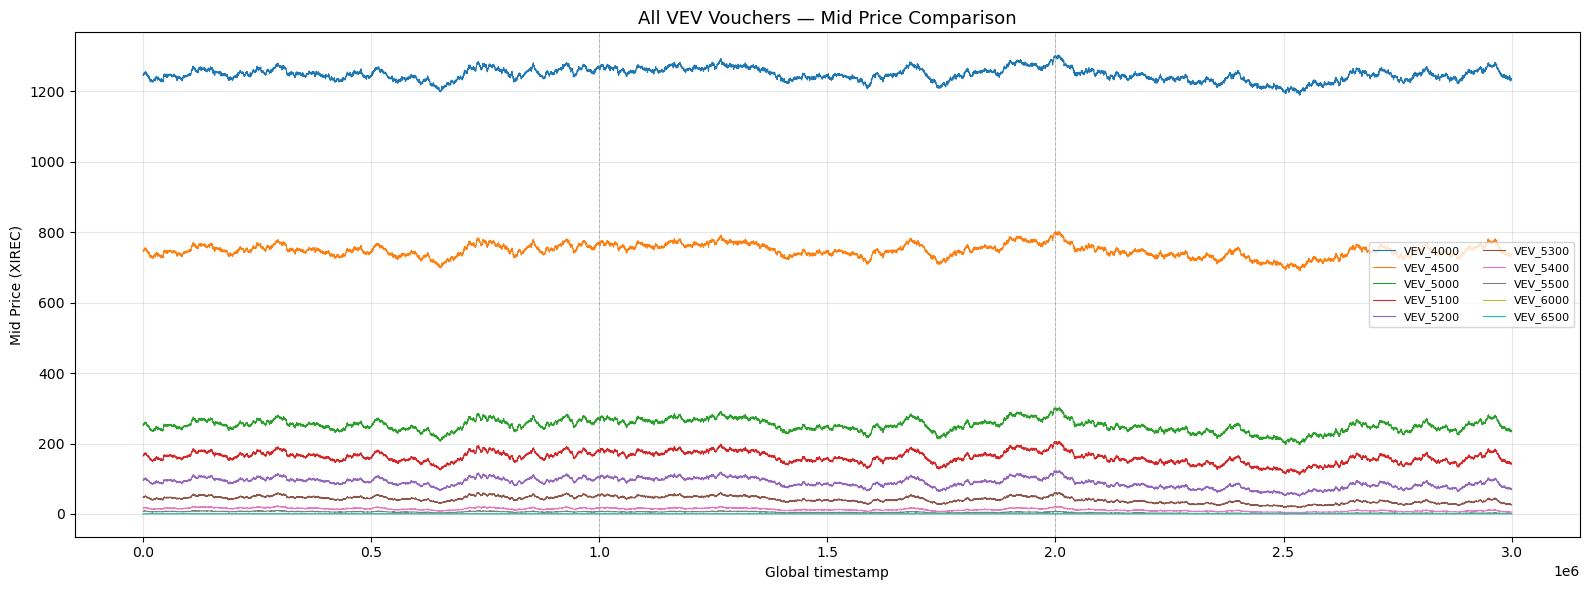

In [4]:
voucher_colors = plt.cm.tab10(np.linspace(0, 1, len(VOUCHERS)))

fig, ax = plt.subplots(figsize=(16, 6))
for col, voucher in zip(voucher_colors, VOUCHERS):
    vdf = prices_df[prices_df["product"] == voucher]
    ax.plot(vdf["global_ts"], vdf["mid_price"],
            color=col, lw=0.8, label=voucher)
for i in range(1, len(days)):
    ax.axvline(i * ticks_per_day, color="grey", ls="--", lw=0.7, alpha=0.5)
ax.set_title("All VEV Vouchers — Mid Price Comparison", fontsize=13)
ax.set_xlabel("Global timestamp")
ax.set_ylabel("Mid Price (XIREC)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

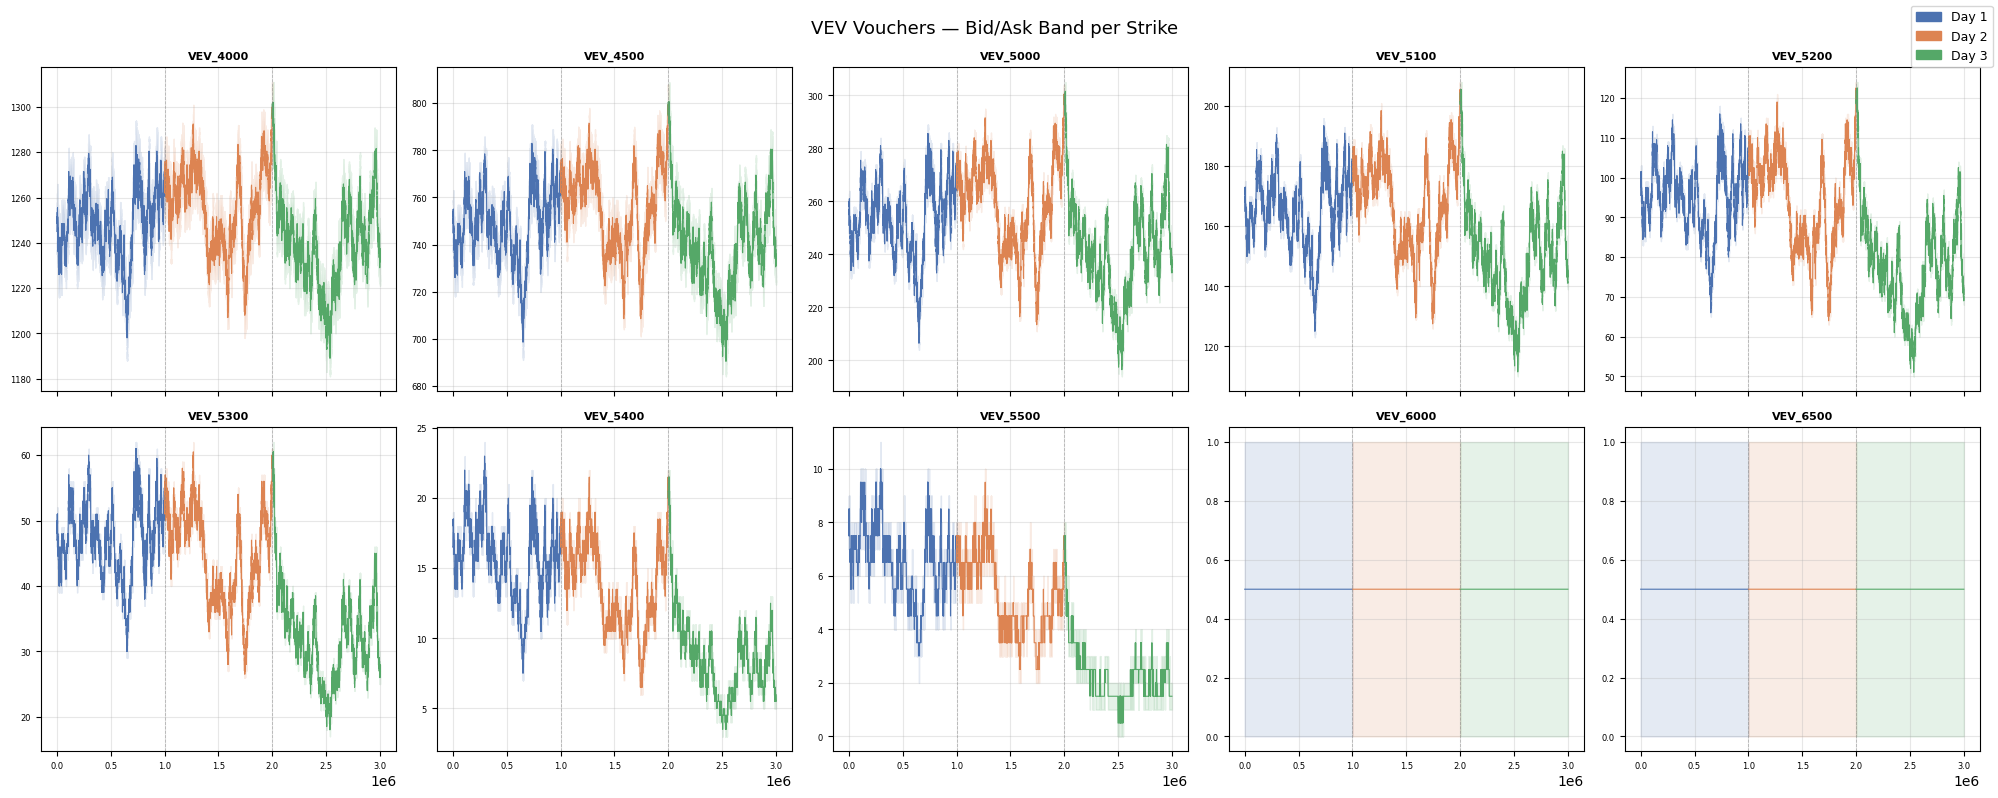

In [5]:
# Individual voucher bid/ask per day
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True)
axes = axes.flatten()

for idx, voucher in enumerate(VOUCHERS):
    ax = axes[idx]
    vdf = prices_df[prices_df["product"] == voucher].copy()
    for d in days:
        sub = vdf[vdf["day"] == d]
        ax.plot(sub["global_ts"], sub["mid_price"],
                color=day_colors[d], lw=0.8)
        ax.fill_between(sub["global_ts"],
                        sub["bid_price_1"].fillna(sub["mid_price"]),
                        sub["ask_price_1"].fillna(sub["mid_price"]),
                        color=day_colors[d], alpha=0.15)
    for i in range(1, len(days)):
        ax.axvline(i * ticks_per_day, color="grey", ls="--", lw=0.6, alpha=0.5)
    ax.set_title(voucher.replace("VELVETFRUIT_EXTRACT_", ""), fontsize=8, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=6)

day_patches = [mpatches.Patch(color=day_colors[d], label=day_labels[d]) for d in days]
fig.legend(handles=day_patches, loc="upper right", fontsize=9)
fig.suptitle("VEV Vouchers — Bid/Ask Band per Strike", fontsize=13)
plt.tight_layout()
plt.show()

## 5 — Counterparty Analysis: Volume by Product

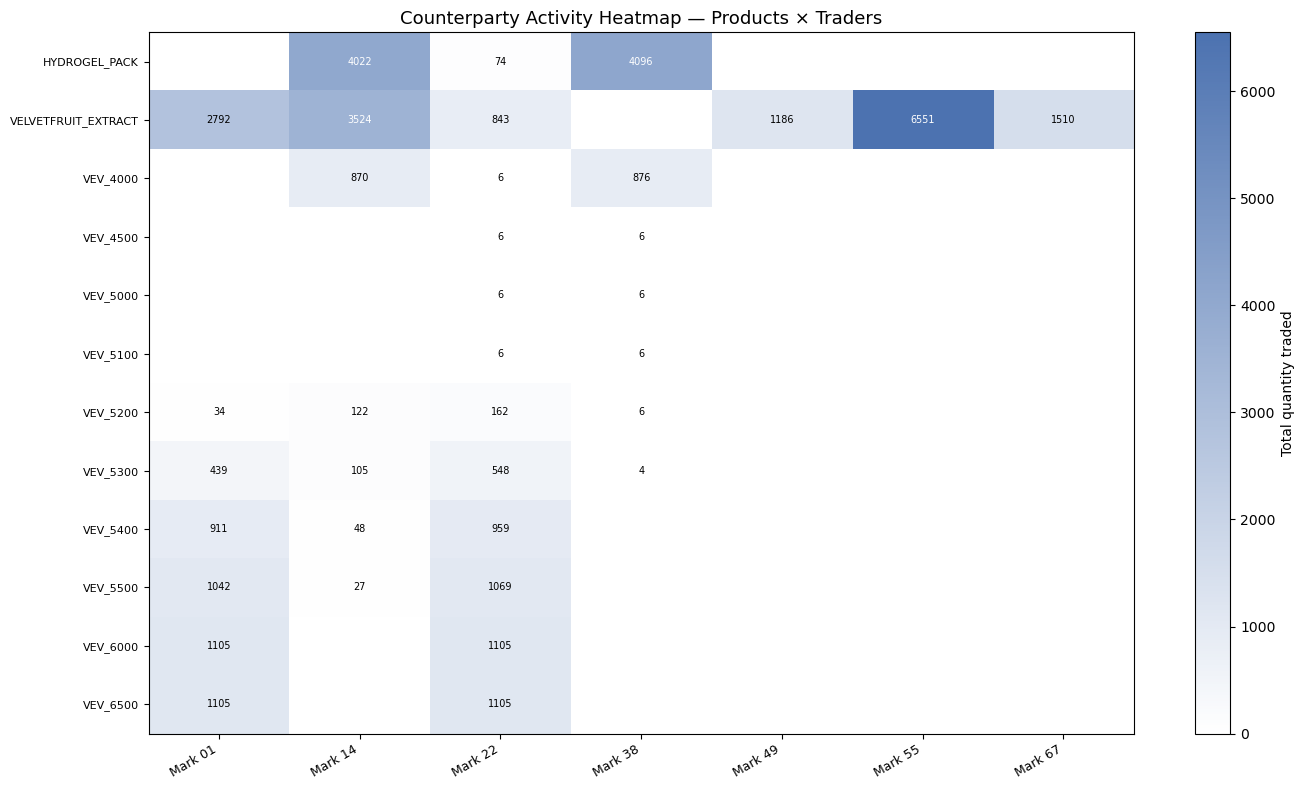

In [6]:
# Melt trades into long form (one row per trader-side)
buy_side  = trades_df[["symbol", "buyer",  "quantity", "global_ts", "day", "price"]].copy()
sell_side = trades_df[["symbol", "seller", "quantity", "global_ts", "day", "price"]].copy()
buy_side.columns  = ["product", "trader", "quantity", "global_ts", "day", "price"]
sell_side.columns = ["product", "trader", "quantity", "global_ts", "day", "price"]
buy_side["side"]  = "buy"
sell_side["side"] = "sell"
activity = pd.concat([buy_side, sell_side], ignore_index=True)
activity = activity[activity["trader"].notna()]

# Heatmap: products × traders (total quantity)
heat = activity.groupby(["product", "trader"])["quantity"].sum().unstack(fill_value=0)
heat = heat.reindex(columns=TRADERS, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 8))
cmap = LinearSegmentedColormap.from_list("wbl", ["white", "#4C72B0"])
im = ax.imshow(heat.values, aspect="auto", cmap=cmap)
ax.set_xticks(range(len(TRADERS)))
ax.set_xticklabels(TRADERS, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=8)
for i in range(len(heat.index)):
    for j in range(len(TRADERS)):
        val = int(heat.values[i, j])
        if val > 0:
            ax.text(j, i, val, ha="center", va="center", fontsize=7,
                    color="white" if val > heat.values.max() * 0.5 else "black")
plt.colorbar(im, ax=ax, label="Total quantity traded")
ax.set_title("Counterparty Activity Heatmap — Products × Traders", fontsize=13)
plt.tight_layout()
plt.show()

## 6 — Per-Product: Buyer vs Seller Volume by Counterparty

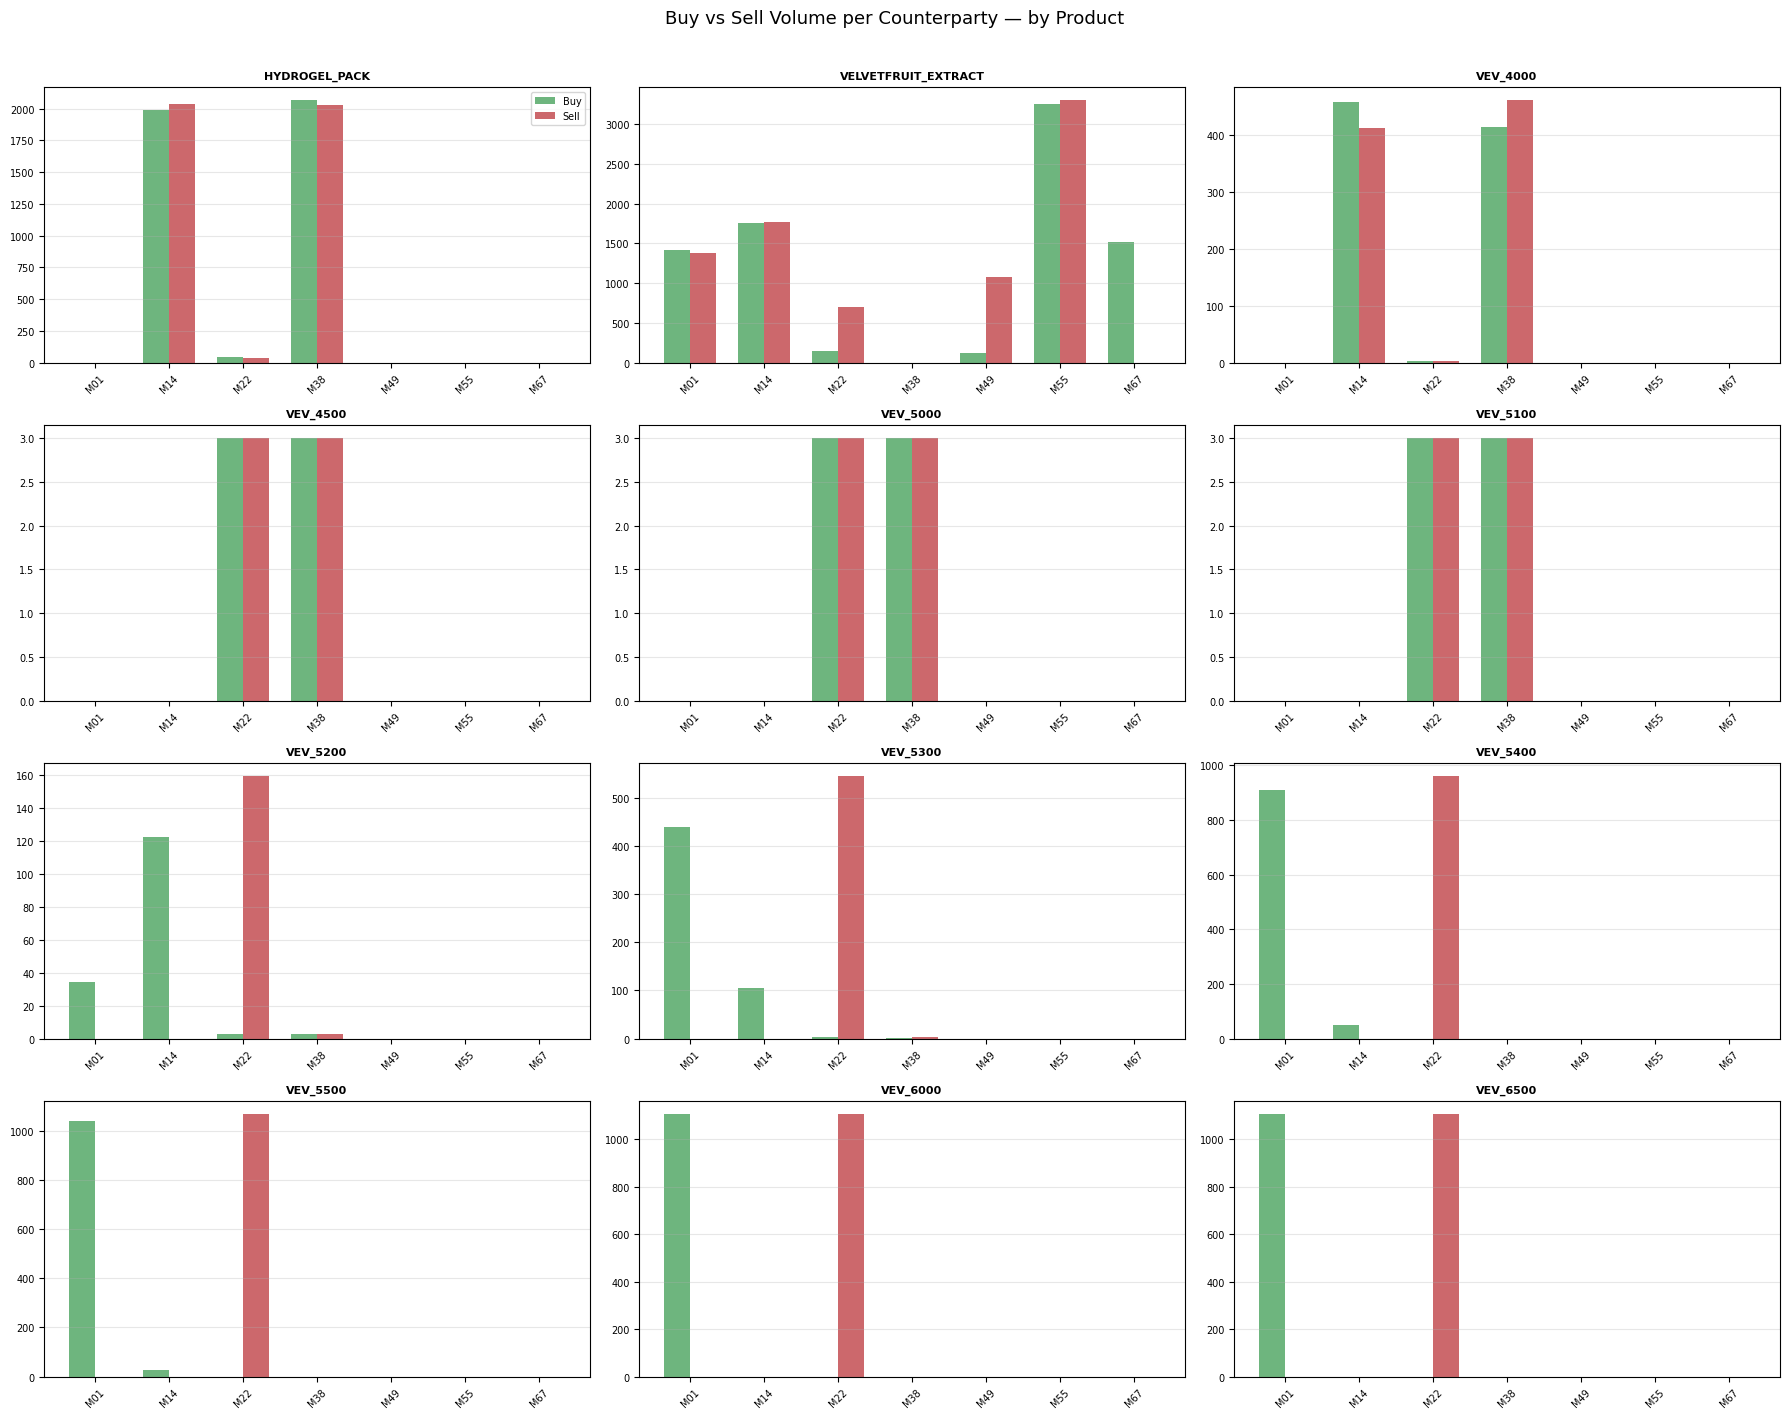

In [7]:
ncols = 3
nrows = int(np.ceil(len(PRODUCTS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

trader_colors = {t: c for t, c in zip(TRADERS, plt.cm.Set2(np.linspace(0, 1, len(TRADERS))))}

for idx, product in enumerate(PRODUCTS):
    ax = axes[idx]
    prod_act = activity[activity["product"] == product]
    by_side = prod_act.groupby(["trader", "side"])["quantity"].sum().unstack(fill_value=0)
    for col in ["buy", "sell"]:
        if col not in by_side.columns:
            by_side[col] = 0
    by_side = by_side.reindex(TRADERS, fill_value=0)

    x = np.arange(len(TRADERS))
    width = 0.35
    ax.bar(x - width/2, by_side["buy"],  width, label="Buy",  color="#55A868", alpha=0.85)
    ax.bar(x + width/2, by_side["sell"], width, label="Sell", color="#C44E52", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([t.replace("Mark ", "M") for t in TRADERS], fontsize=7, rotation=45)
    ax.set_title(product, fontsize=8, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    ax.tick_params(labelsize=7)
    if idx == 0:
        ax.legend(fontsize=7)

for j in range(len(PRODUCTS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Buy vs Sell Volume per Counterparty — by Product", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7 — Counterparty Behaviour Over Time

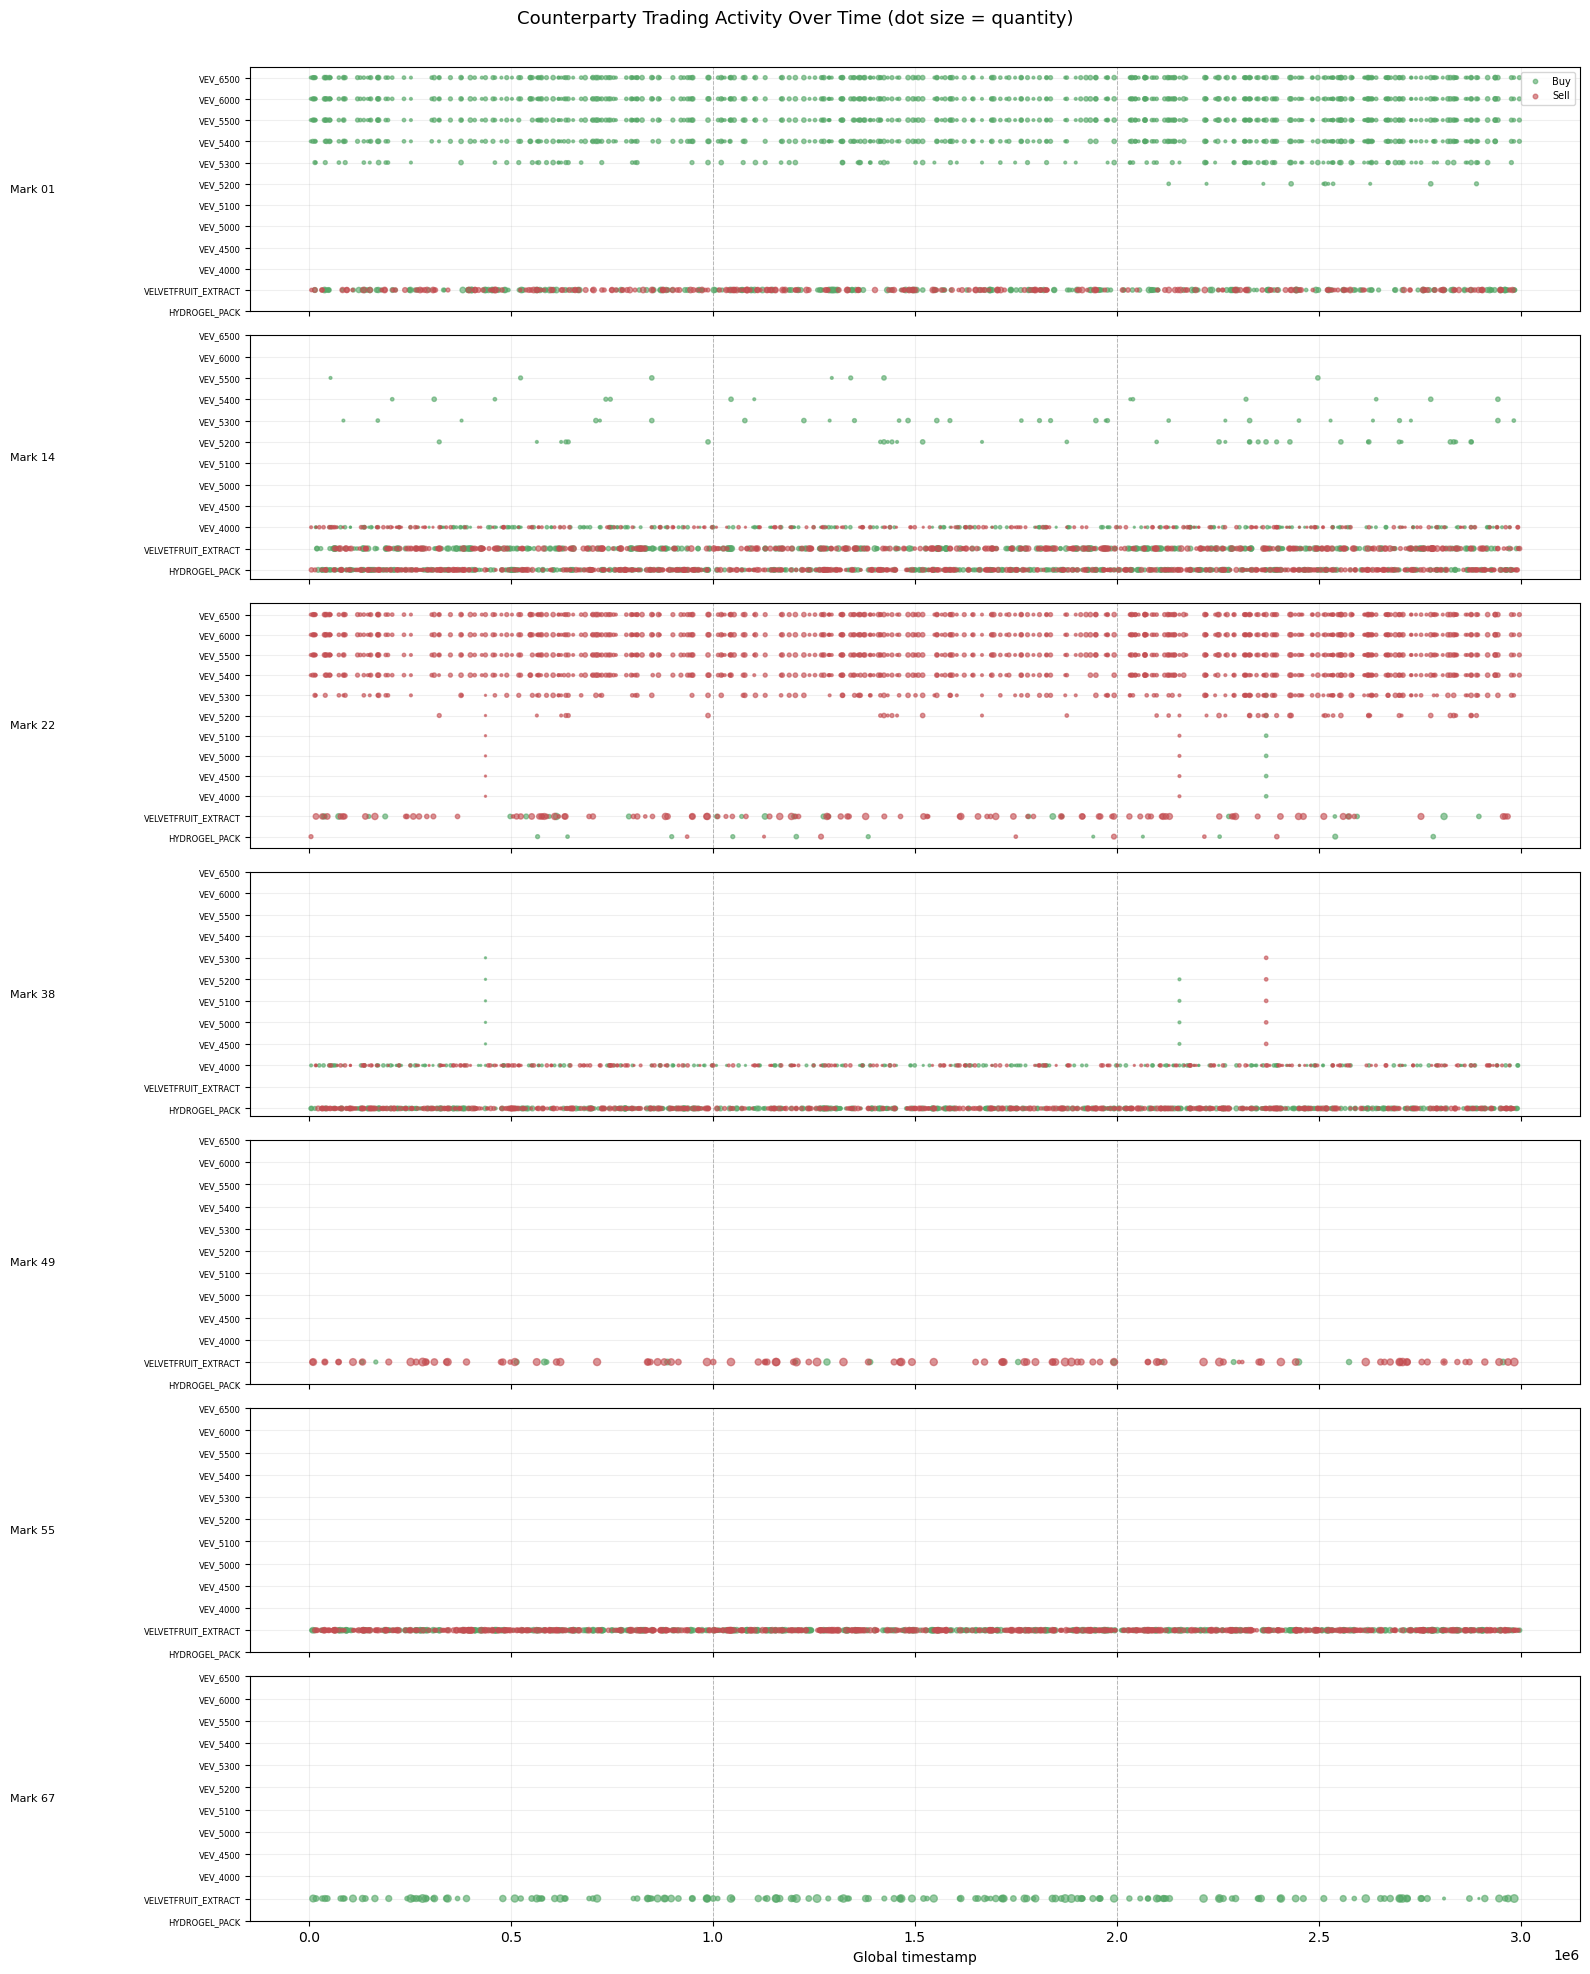

In [8]:
# Scatter: x=global_ts, y=product, colour=buy/sell, size=quantity
product_idx = {p: i for i, p in enumerate(PRODUCTS)}
activity["product_num"] = activity["product"].map(product_idx)

fig, axes = plt.subplots(len(TRADERS), 1,
                         figsize=(16, len(TRADERS) * 2.8), sharex=True)

for ax, trader in zip(axes, TRADERS):
    tdf = activity[activity["trader"] == trader]
    buy_t  = tdf[tdf["side"] == "buy"]
    sell_t = tdf[tdf["side"] == "sell"]

    ax.scatter(buy_t["global_ts"],  buy_t["product_num"],
               s=buy_t["quantity"] * 2, color="#55A868", alpha=0.6,
               label="Buy",  zorder=3)
    ax.scatter(sell_t["global_ts"], sell_t["product_num"],
               s=sell_t["quantity"] * 2, color="#C44E52", alpha=0.6,
               label="Sell", zorder=3)

    for i in range(1, len(days)):
        ax.axvline(i * ticks_per_day, color="grey", ls="--", lw=0.7, alpha=0.5)
    ax.set_yticks(list(product_idx.values()))
    ax.set_yticklabels(list(product_idx.keys()), fontsize=6)
    ax.set_ylabel(trader, fontsize=8, rotation=0, labelpad=80, va="center")
    ax.grid(True, alpha=0.2)
    if ax == axes[0]:
        ax.legend(fontsize=7, loc="upper right")

axes[-1].set_xlabel("Global timestamp")
fig.suptitle("Counterparty Trading Activity Over Time (dot size = quantity)",
             fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

In [9]:
# Per-trader: total volume per product and trade count
summary = activity.groupby(["trader", "product", "side"])["quantity"].agg(["sum", "count"]).reset_index()
summary.columns = ["trader", "product", "side", "total_qty", "n_trades"]
print(summary.sort_values(["trader", "product", "side"]).to_string(index=False))

 trader             product side  total_qty  n_trades
Mark 01 VELVETFRUIT_EXTRACT  buy       1417       260
Mark 01 VELVETFRUIT_EXTRACT sell       1375       244
Mark 01            VEV_5200  buy         34        11
Mark 01            VEV_5300  buy        439       132
Mark 01            VEV_5400  buy        911       263
Mark 01            VEV_5500  buy       1042       299
Mark 01            VEV_6000  buy       1105       317
Mark 01            VEV_6500  buy       1105       317
Mark 14       HYDROGEL_PACK  buy       1989       496
Mark 14       HYDROGEL_PACK sell       2033       507
Mark 14 VELVETFRUIT_EXTRACT  buy       1761       316
Mark 14 VELVETFRUIT_EXTRACT sell       1763       331
Mark 14            VEV_4000  buy        458       232
Mark 14            VEV_4000 sell        412       207
Mark 14            VEV_5200  buy        122        33
Mark 14            VEV_5300  buy        105        30
Mark 14            VEV_5400  buy         48        13
Mark 14            VEV_5500 

## 8 — Counterparty Interaction Network

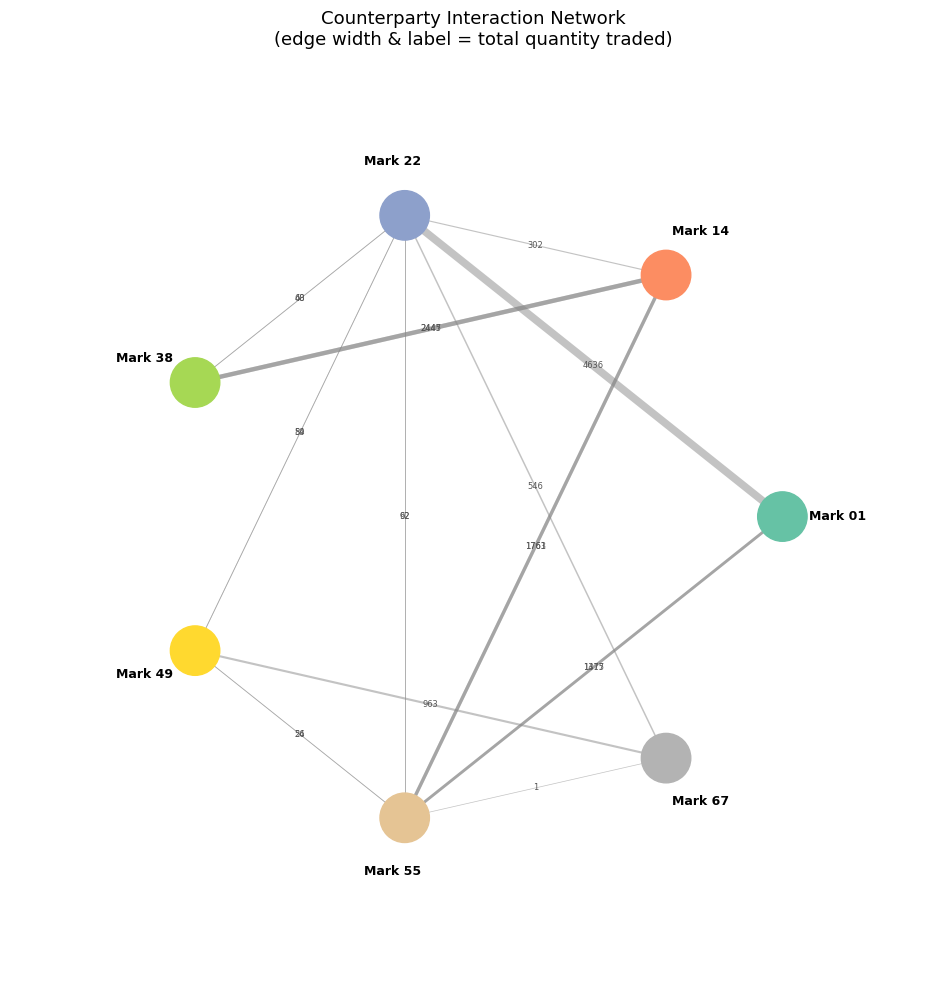

In [10]:
# Edge weight = total quantity traded between each buyer-seller pair
pairs = trades_df.dropna(subset=["buyer", "seller"]).groupby(["buyer", "seller"])["quantity"].sum().reset_index()
pairs.columns = ["buyer", "seller", "volume"]

# node positions on a circle
n = len(TRADERS)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
pos = {t: (np.cos(a), np.sin(a)) for t, a in zip(TRADERS, angles)}

max_vol = pairs["volume"].max()

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect("equal")
ax.axis("off")

# draw edges
for _, row in pairs.iterrows():
    x1, y1 = pos[row["buyer"]]
    x2, y2 = pos[row["seller"]]
    lw = 0.5 + 5 * (row["volume"] / max_vol)
    ax.plot([x1, x2], [y1, y2], color="#888888", lw=lw, alpha=0.5, zorder=1)
    # arrow mid-point annotation
    mx, my = (x1 + x2) / 2, (y1 + y2) / 2
    ax.text(mx, my, str(int(row["volume"])), fontsize=6, ha="center", va="center",
            color="#555555", zorder=4)

# draw nodes
node_colors = plt.cm.Set2(np.linspace(0, 1, n))
for (trader, (x, y)), col in zip(pos.items(), node_colors):
    circle = plt.Circle((x, y), 0.08, color=col, zorder=5)
    ax.add_patch(circle)
    ax.text(x * 1.18, y * 1.18, trader, ha="center", va="center",
            fontsize=9, fontweight="bold", zorder=6)

ax.set_title("Counterparty Interaction Network\n(edge width & label = total quantity traded)",
             fontsize=13)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
plt.tight_layout()
plt.show()

In [11]:
# Edge breakdown by product
pairs_by_product = (trades_df
    .dropna(subset=["buyer", "seller"])
    .groupby(["buyer", "seller", "symbol"])["quantity"]
    .sum()
    .reset_index()
    .sort_values(["buyer", "seller", "quantity"], ascending=[True, True, False])
)
print(pairs_by_product.to_string(index=False))

  buyer  seller              symbol  quantity
Mark 01 Mark 22            VEV_6000      1105
Mark 01 Mark 22            VEV_6500      1105
Mark 01 Mark 22            VEV_5500      1042
Mark 01 Mark 22            VEV_5400       911
Mark 01 Mark 22            VEV_5300       439
Mark 01 Mark 22            VEV_5200        34
Mark 01 Mark 55 VELVETFRUIT_EXTRACT      1417
Mark 14 Mark 22            VEV_5200       122
Mark 14 Mark 22            VEV_5300       105
Mark 14 Mark 22            VEV_5400        48
Mark 14 Mark 22            VEV_5500        27
Mark 14 Mark 38       HYDROGEL_PACK      1989
Mark 14 Mark 38            VEV_4000       458
Mark 14 Mark 55 VELVETFRUIT_EXTRACT      1761
Mark 22 Mark 38       HYDROGEL_PACK        42
Mark 22 Mark 38            VEV_4000         3
Mark 22 Mark 38            VEV_4500         3
Mark 22 Mark 38            VEV_5000         3
Mark 22 Mark 38            VEV_5100         3
Mark 22 Mark 38            VEV_5200         3
Mark 22 Mark 38            VEV_530